# Beta, stratification, and Burger-number hypotheses

This notebook asks whether the equatorward increase in measured `TiltDis` is better described by beta alone, stratification, `N2/f²`, a transparent deformation-radius/Burger proxy, or background shear. Beta is inseparable from latitude, so spatial robustness and comparisons among competing predictors are central.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [2]:
N2_CACHE = mech.DEFAULT_N2_CACHE_PATH
n2 = mech.load_stratification_cache(N2_CACHE)
data = mech.merge_one_to_one_or_many_to_one(df, n2)
for depth in (200, 500):
    data[f"N2_{depth}m_s2"] = data[f"N2_{depth}m_core_s2"]
data = tilt.add_pv_gradient_terms(data, grid)
data = mech.add_stratification_proxies(data)
data = mech.add_tilt_components(data)
print('AE')
data[data.Cyc=='AE'][["TiltDis", "beta", "N2_500m_s2", "N2_over_f2_500m", "Bu_proxy_500m"]].describe()

AE


,TiltDis,beta,N2_500m_s2,N2_over_f2_500m,Bu_proxy_500m
count,53607.000000,6.495000e+04,64952.000000,64952.000000,64952.000000
mean,26.080512,1.909077e-11,0.000031,4936.894372,0.028865
std,22.617269,7.920902e-13,0.000014,2883.935180,0.033709
min,0.010263,1.755648e-11,0.000003,348.594109,0.001064
25%,10.490095,1.840303e-11,0.000020,2707.476157,0.009296
50%,19.609894,1.897062e-11,0.000029,4416.510682,0.018662
75%,34.752937,1.979213e-11,0.000041,6483.243342,0.035609
max,266.951190,2.076522e-11,0.000093,19607.653376,0.697416


In [3]:
print('CE')
data[data.Cyc=='CE'][["TiltDis", "beta", "N2_500m_s2", "N2_over_f2_500m", "Bu_proxy_500m"]].describe()

CE


,TiltDis,beta,N2_500m_s2,N2_over_f2_500m,Bu_proxy_500m
count,52014.000000,6.247400e+04,62474.000000,62474.000000,62474.000000
mean,21.584768,1.926012e-11,0.000036,5994.861824,0.043513
std,18.963101,8.227682e-13,0.000017,3721.081896,0.057539
min,0.010924,1.758943e-11,0.000004,522.202962,0.001422
25%,8.708036,1.853122e-11,0.000023,3339.822439,0.014000
50%,16.008249,1.919284e-11,0.000034,5244.366362,0.026717
75%,28.298188,2.001376e-11,0.000046,7917.387492,0.051893
max,202.385991,2.082975e-11,0.000281,55780.740792,2.795633


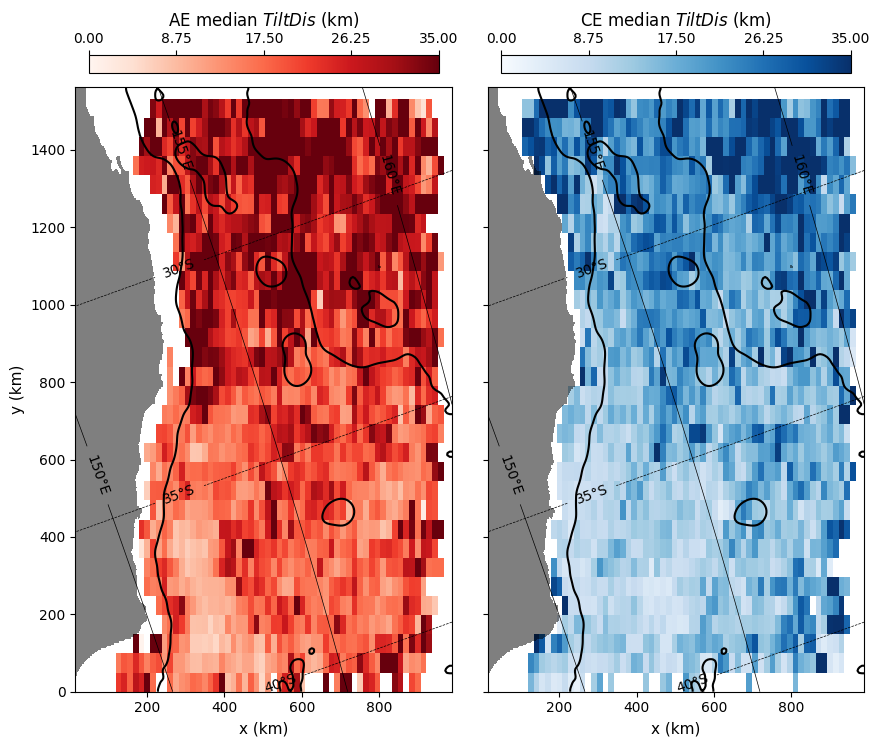

In [4]:
fig, axs = tilt.plot_binned_median_map(data.copy(), grid, 
                                       metric='TiltDis', vmin=0, vmax=35)

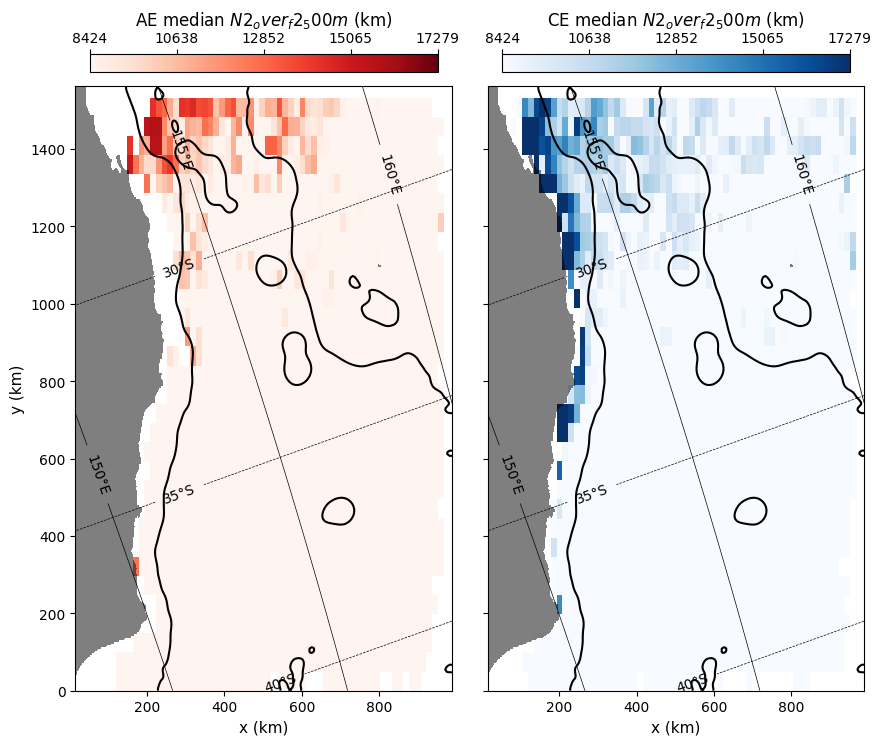

In [5]:
fig, axs = tilt.plot_binned_median_map(data.copy(), grid, 
                                       metric='N2_over_f2_500m', vmin=8424, vmax=17279)

In [6]:
data.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       ...
       'pv_averaging', 'pv_surface_method', 'N2_over_f2_200m',
       'Rd_proxy_200m_km', 'Bu_proxy_200m', 'N2_over_f2_500m',
       'Rd_proxy_500m_km', 'Bu_proxy_500m', 'tilt_east_km', 'tilt_north_km'],
      dtype='object', length=146)

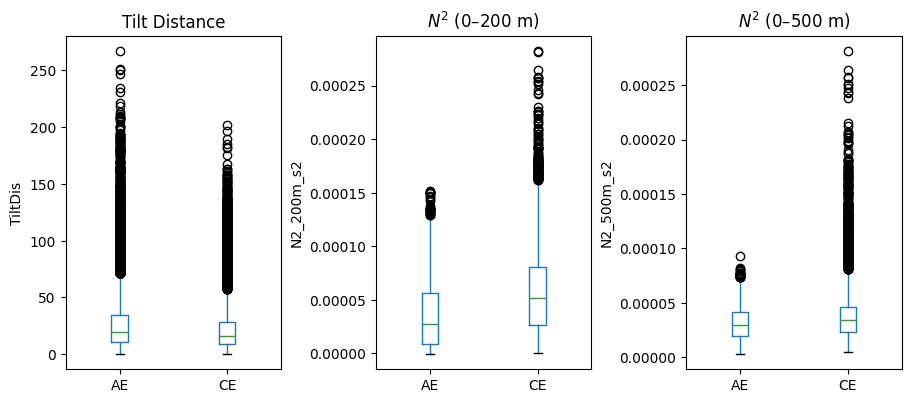

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(9, 4), constrained_layout=True)

cols = ['TiltDis', 'N2_200m_s2', 'N2_500m_s2']
titles = ['Tilt Distance', r'$N^2$ (0–200 m)', r'$N^2$ (0–500 m)']

for ax, col, title in zip(axs, cols, titles):
    data.boxplot(
        column=col,
        by='Cyc',
        ax=ax,
        grid=False,
        # outliers=False
    )

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(col)

fig.suptitle('')
plt.show() 

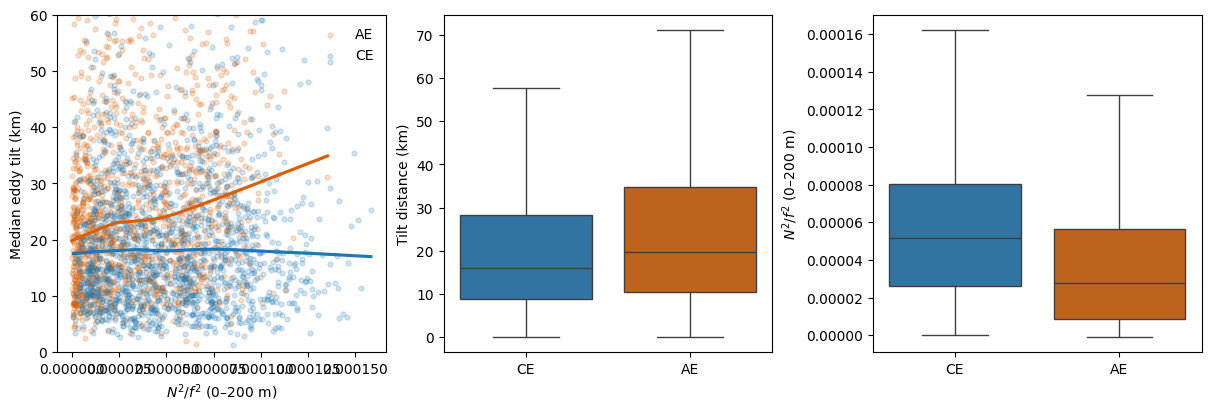

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
palette = {"AE": "#d95f02", "CE": "#1f78b4"}

# --- N2 vs tilt: one point per eddy ---
i = 200
eddy = data.groupby(["Cyc", "Eddy"], as_index=False)[
    ["TiltDis", f"N2_{i}m_s2"]
].median()

for cyc, df in eddy.groupby("Cyc"):
    axs[0].scatter(df[f"N2_{i}m_s2"], df.TiltDis, s=12, alpha=.2,
                   color=palette[cyc], label=cyc)
    sns.regplot(data=df, x=f"N2_{i}m_s2", y="TiltDis", lowess=True,
                scatter=False, color=palette[cyc], ax=axs[0])

axs[0].set(xlabel=rf"$N^2/f^2$ (0–{i} m)", ylabel="Median eddy tilt (km)", ylim=(0, 60))
axs[0].legend(frameon=False)

# --- Boxplots ---
for ax, col, ylabel in zip(
    axs[1:],
    ["TiltDis", "N2_200m_s2"],
    ["Tilt distance (km)", r"$N^2/f^2$ (0–200 m)"]
):
    sns.boxplot(data=data, x="Cyc", y=col, hue="Cyc",
                palette=palette, legend=False, showfliers=False, ax=ax)
    ax.set(xlabel="", ylabel=ylabel)

plt.show()

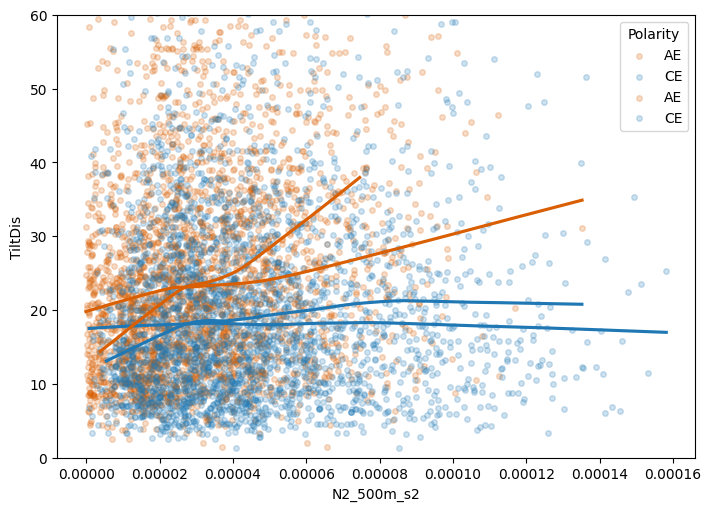

In [9]:
# One point per eddy: repeated daily rows are not plotted as independent samples.
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for i in [200, 500]:
    eddy_preview = (data.groupby(["Cyc", "Eddy"], as_index=False)
                    [["TiltDis", f"N2_{i}m_s2"]].median())
    for cyc, part in eddy_preview.groupby("Cyc"):
        ax.scatter(part[f'N2_{i}m_s2'], part.TiltDis, s=16, alpha=.22,
                   color=palette[cyc], label=cyc)
        sns.regplot(data=part, x=f"N2_{i}m_s2", y="TiltDis", lowess=True,
                    scatter=False, color=palette[cyc], ax=ax)
# ax.set(xlabel=r"$N^2/f^2$ (0-500 m core mean)", ylabel="Median eddy tilt (km)",
#        title=r"Eddy-level tilt relationship with $N^2/f^2$")
ax.legend(title="Polarity"); ax.set_ylim(0, 60)
plt.show()

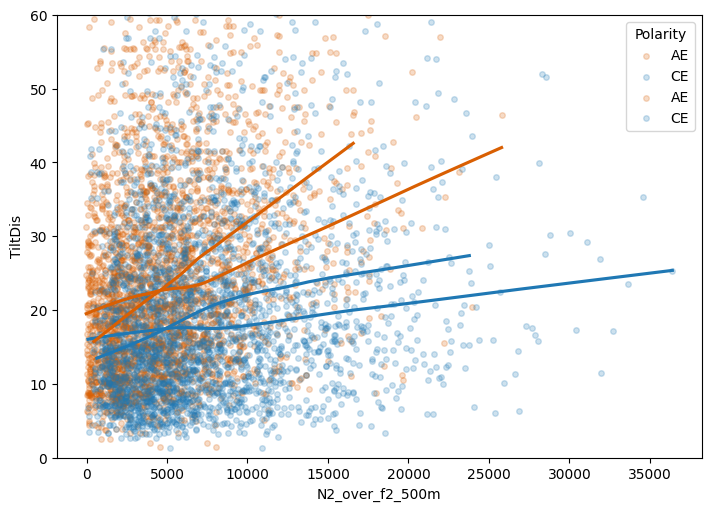

In [10]:
# One point per eddy: repeated daily rows are not plotted as independent samples.
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for i in [200,500]:
    eddy_preview = (data.groupby(["Cyc", "Eddy"], as_index=False)
                    [["TiltDis", f"N2_over_f2_{i}m"]].median())
    
    for cyc, part in eddy_preview.groupby("Cyc"):
        ax.scatter(part[f'N2_over_f2_{i}m'], part.TiltDis, s=16, alpha=.22,
                   color=palette[cyc], label=cyc)
        sns.regplot(data=part, x=f"N2_over_f2_{i}m", y="TiltDis", lowess=True,
                    scatter=False, color=palette[cyc], ax=ax)
# ax.set(xlabel=r"$N^2/f^2$ (0-500 m core mean)", ylabel="Median eddy tilt (km)",
#        title=r"Eddy-level tilt relationship with $N^2/f^2$")
ax.legend(title="Polarity"); ax.set_ylim(0, 60)
plt.show()

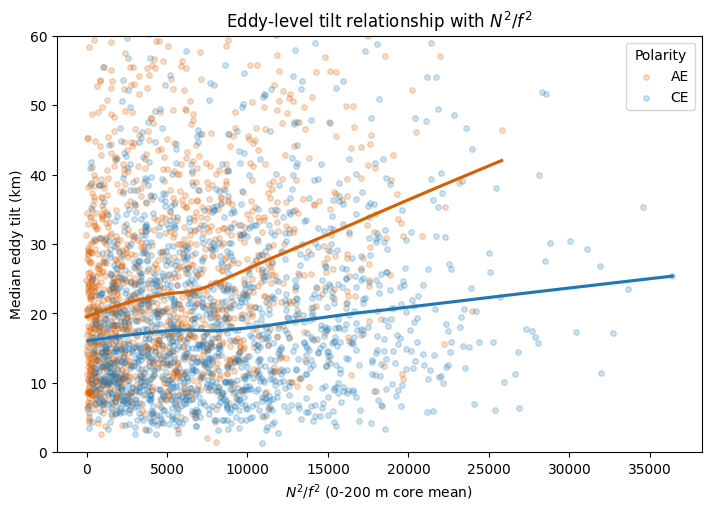

In [11]:
# One point per eddy: repeated daily rows are not plotted as independent samples.
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
eddy_preview = (data.groupby(["Cyc", "Eddy"], as_index=False)
                [["TiltDis", "N2_over_f2_200m"]].median())
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for cyc, part in eddy_preview.groupby("Cyc"):
    ax.scatter(part.N2_over_f2_200m, part.TiltDis, s=16, alpha=.22,
               color=palette[cyc], label=cyc)
    sns.regplot(data=part, x="N2_over_f2_200m", y="TiltDis", lowess=True,
                scatter=False, color=palette[cyc], ax=ax)
ax.set(xlabel=r"$N^2/f^2$ (0-200 m core mean)", ylabel="Median eddy tilt (km)",
       title=r"Eddy-level tilt relationship with $N^2/f^2$")
ax.legend(title="Polarity"); ax.set_ylim(0, 60)
plt.show()

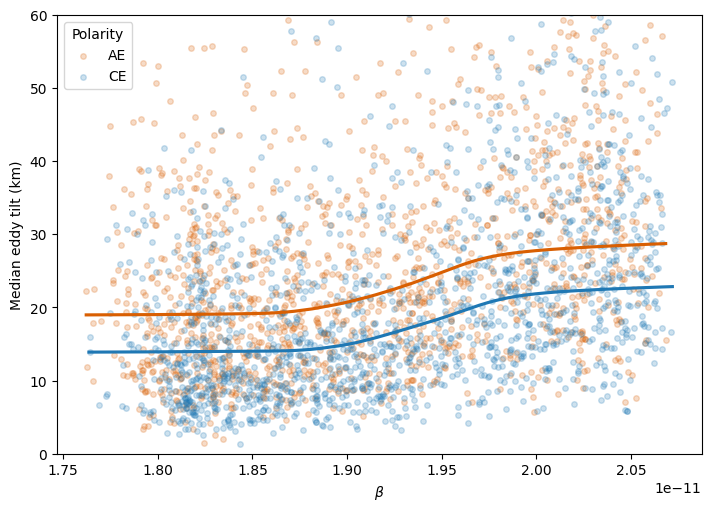

In [12]:
# One point per eddy: repeated daily rows are not plotted as independent samples.
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
eddy_preview = (data.groupby(["Cyc", "Eddy"], as_index=False)
                [["TiltDis", "beta"]].median())
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for cyc, part in eddy_preview.groupby("Cyc"):
    ax.scatter(part.beta, part.TiltDis, s=16, alpha=.22,
               color=palette[cyc], label=cyc)
    sns.regplot(data=part, x="beta", y="TiltDis", lowess=True,
                scatter=False, color=palette[cyc], ax=ax)
ax.set(xlabel=r"$\beta$", ylabel="Median eddy tilt (km)")
ax.legend(title="Polarity"); ax.set_ylim(0, 60)
plt.show()

In [13]:
predictors = ["beta", "N2_200m_s2", "N2_500m_s2", "N2_over_f2_200m",
              "N2_over_f2_500m", "Rd_proxy_500m_km", "Bu_proxy_500m", "Rc", "h"]
eddy = data.groupby(["Cyc", "Eddy"], as_index=False)[["TiltDis", *predictors]].median()
rows = []
from scipy.stats import spearmanr
for cyc, part in eddy.groupby("Cyc"):
    for predictor in predictors:
        use = part[[predictor, "TiltDis"]].dropna()
        rho, p = spearmanr(use[predictor], use["TiltDis"])
        rows.append({"Cyc": cyc, "predictor": predictor, "eddies": len(use), "rho": rho, "p": p})
display(pd.DataFrame(rows).sort_values(["Cyc", "rho"], ascending=[True, False]))


,Cyc,predictor,eddies,rho,p
0,AE,beta,1422,0.378848,9.387163e-50
4,AE,N2_over_f2_500m,1422,0.354649,2.118692e-43
5,AE,Rd_proxy_500m_km,1422,0.354642,2.126465e-43
6,AE,Bu_proxy_500m,1422,0.277406,1.539878e-26
2,AE,N2_500m_s2,1422,0.273755,7.322728e-26
3,AE,N2_over_f2_200m,1422,0.229965,1.603579e-18
1,AE,N2_200m_s2,1422,0.170141,1.065225e-10
7,AE,Rc,1422,-0.038845,1.431697e-01
8,AE,h,1422,-0.221517,2.884887e-17
9,CE,beta,1531,0.440298,1.302175e-73


In [14]:
# Compare predeclared clustered models; coefficients are standardised for scale comparability.
import statsmodels.formula.api as smf

model_sets = {
    "structure_environment": ["Rc", "h"],
    "plus_beta": ["Rc", "h", "beta"],
    "plus_N2": ["Rc", "h", "beta", "N2_500m_s2"],
    "N2_over_f2": ["Rc", "h", "beta", "N2_over_f2_500m"],
    "Burger_proxy": ["Rc", "h", "beta", "Bu_proxy_500m"],
}
fits, comparison = {}, []
for cyc, part in data.groupby("Cyc"):
    for name, cols in model_sets.items():
        use = part[["Eddy", "TiltDis", *cols]].dropna().copy()
        for col in cols:
            use[f"z_{col}"] = (use[col] - use[col].mean()) / use[col].std()
        fit = smf.gee("np.log1p(TiltDis) ~ " + " + ".join(f"z_{c}" for c in cols),
                      groups="Eddy", data=use).fit()
        fits[(cyc, name)] = fit
        # A common fixed scale is required for valid QIC comparison.
        qic = fit.qic(scale=1.0)[0] if callable(getattr(fit, "qic", None)) else np.nan
        comparison.append({"Cyc": cyc, "model": name, "rows": len(use),
                           "eddies": use.Eddy.nunique(), "QIC": qic})
display(pd.DataFrame(comparison))


,Cyc,model,rows,eddies,QIC
0,AE,structure_environment,53607,1422,34775.972500
1,AE,plus_beta,53607,1422,31750.855736
2,AE,plus_N2,53607,1422,31215.342962
3,AE,N2_over_f2,53607,1422,31323.855153
4,AE,Burger_proxy,53607,1422,31758.578520
5,CE,structure_environment,52014,1531,32336.606257
6,CE,plus_beta,52014,1531,28925.923342
7,CE,plus_N2,52014,1531,28758.683212
8,CE,N2_over_f2,52014,1531,28805.078408
9,CE,Burger_proxy,52014,1531,28927.404530


In [15]:
# Spatial sensitivity: repeat within broad latitude and shelf regimes.
data["latitude_band"] = pd.cut(data["lat" if "lat" in data else "yc"], 4)
spatial = (data.groupby(["Cyc", "latitude_band"], observed=True)
           .agg(rows=("TiltDis", "size"), eddies=("Eddy", "nunique"),
                tilt=("TiltDis", "median"), n2=("N2_500m_s2", "median"),
                beta=("beta", "median"), burger=("Bu_proxy_500m", "median")))
display(spatial)


rows  eddies       tilt        n2          beta  \
Cyc latitude_band                                                          
AE  (-40.912, -37.101]  18945     499  14.410548  0.000019  1.819594e-11   
    (-37.101, -33.305]  22094     569  16.381239  0.000029  1.886830e-11   
    (-33.305, -29.509]  14574     491  27.542649  0.000035  1.976628e-11   
    (-29.509, -25.712]   9339     307  31.077719  0.000040  2.032352e-11   
CE  (-40.912, -37.101]  15086     481  11.388181  0.000022  1.821356e-11   
    (-37.101, -33.305]  19261     592  12.295903  0.000032  1.890570e-11   
    (-33.305, -29.509]  15483     545  20.177048  0.000040  1.980586e-11   
    (-29.509, -25.712]  12644     366  25.441802  0.000046  2.038718e-11   

                          burger  
Cyc latitude_band                 
AE  (-40.912, -37.101]  0.016494  
    (-37.101, -33.305]  0.013880  
    (-33.305, -29.509]  0.021511  
    (-29.509, -25.712]  0.039197  
CE  (-40.912, -37.101]  0.019741  
    (-37.101, -33.305]  0.019922  
    (-33.305, -29.509]  0.029527  
    (-29.509, -25.712]  0.051683

In [16]:
# Eddy-level tertiles avoid treating repeated eddy-days as independent categories.
latitude_col = "lat" if "lat" in data else "yc"
data = mech.add_eddy_stratification_categories(
    data, "N2_500m_s2", class_col="N2Class"
)
data = mech.add_eddy_stratification_categories(
    data, "N2_500m_s2", class_col="N2ClassLatitudeAdjusted", latitude_col=latitude_col
)
eddy_strat = (data.groupby(["Cyc", "Eddy"], as_index=False, observed=True)
              .agg(TiltDis=("TiltDis", "median"),
                   N2_500m_s2=("N2_500m_s2", "median"),
                   N2_500m_centre_s2=("N2_500m_centre_s2", "median"),
                   latitude=(latitude_col, "median"),
                   N2Class=("N2Class", "first"),
                   N2ClassLatitudeAdjusted=("N2ClassLatitudeAdjusted", "first")))
category_summary = (eddy_strat.groupby(["Cyc", "N2ClassLatitudeAdjusted"], observed=True)
                    .agg(eddies=("Eddy", "nunique"),
                         median_tilt_km=("TiltDis", "median"),
                         median_core_N2=("N2_500m_s2", "median"),
                         median_latitude=("latitude", "median"))
                    .reset_index())
display(category_summary)


,Cyc,N2ClassLatitudeAdjusted,eddies,median_tilt_km,median_core_N2,median_latitude
0,AE,Low,482,20.777231,0.000019,-34.205134
1,AE,Medium,482,21.891604,0.000029,-34.963203
2,AE,High,482,24.418887,0.000045,-34.666306
3,CE,Low,512,19.053081,0.000022,-33.668423
4,CE,Medium,512,16.537649,0.000033,-34.745517
5,CE,High,512,15.923568,0.000050,-34.013026


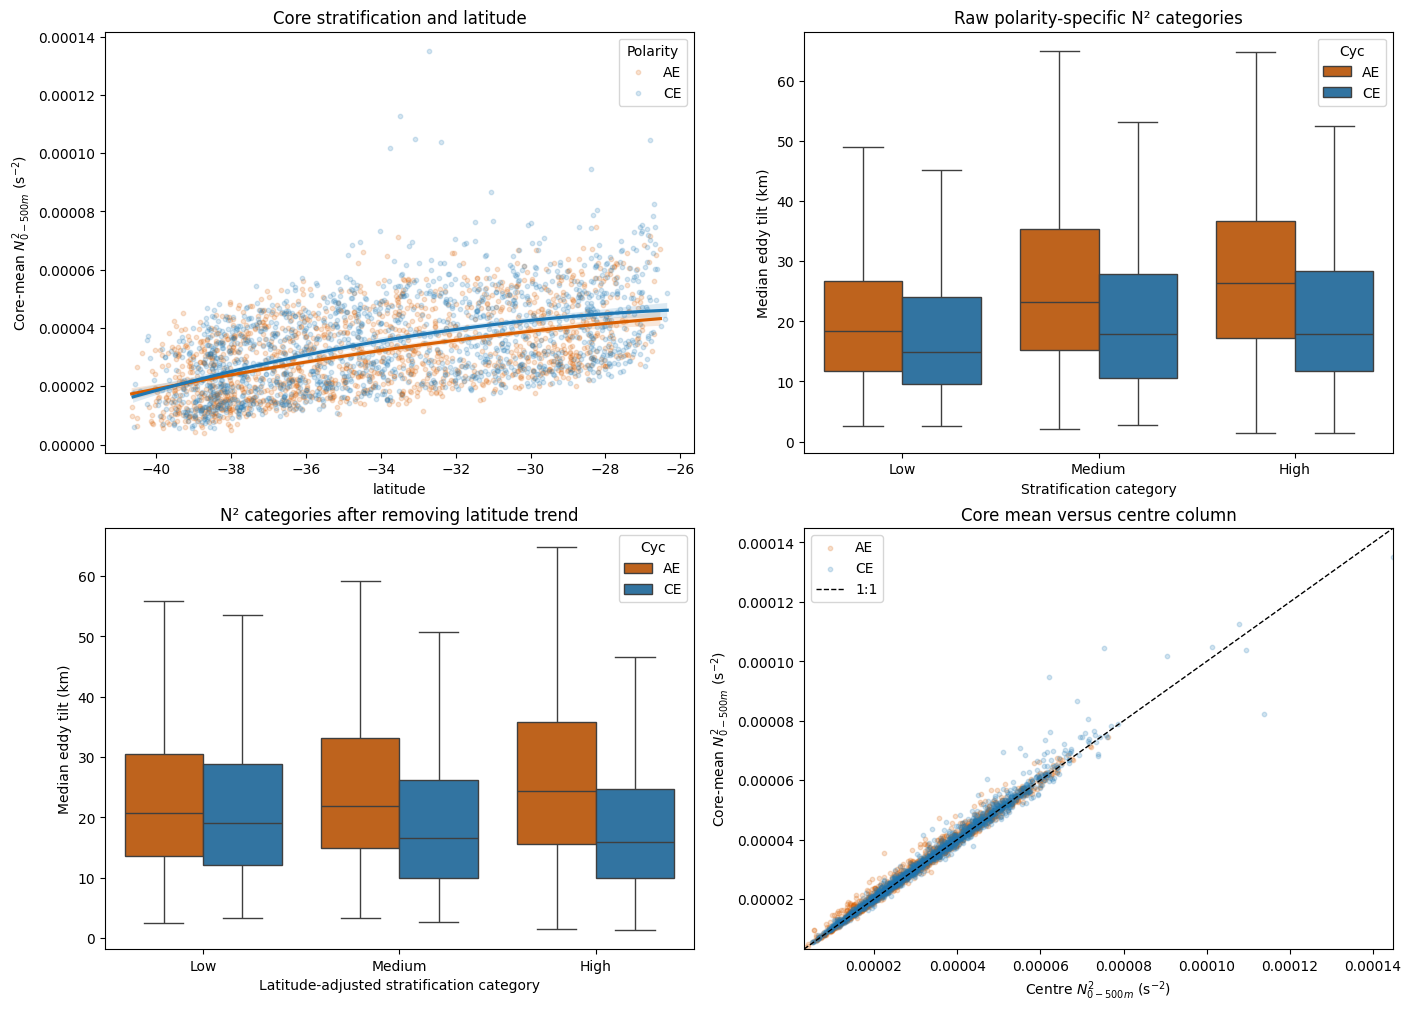

In [17]:
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
order = ["Low", "Medium", "High"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for cyc, part in eddy_strat.groupby("Cyc"):
    axes[0, 0].scatter(part.latitude, part.N2_500m_s2, s=10, alpha=.18,
                       color=palette[cyc], label=cyc)
    sns.regplot(data=part, x="latitude", y="N2_500m_s2", order=2, scatter=False,
                color=palette[cyc], ax=axes[0, 0])
axes[0, 0].set(title="Core stratification and latitude",
               ylabel=r"Core-mean $N^2_{0-500m}$ (s$^{-2}$)")
axes[0, 0].legend(title="Polarity")
sns.boxplot(data=eddy_strat, x="N2Class", y="TiltDis", hue="Cyc", order=order,
            hue_order=["AE", "CE"], palette=palette, showfliers=False, ax=axes[0, 1])
axes[0, 1].set(title="Raw polarity-specific N² categories",
               xlabel="Stratification category", ylabel="Median eddy tilt (km)")
sns.boxplot(data=eddy_strat, x="N2ClassLatitudeAdjusted", y="TiltDis", hue="Cyc",
            order=order, hue_order=["AE", "CE"], palette=palette,
            showfliers=False, ax=axes[1, 0])
axes[1, 0].set(title="N² categories after removing latitude trend",
               xlabel="Latitude-adjusted stratification category",
               ylabel="Median eddy tilt (km)")
sample = eddy_strat.dropna(subset=["N2_500m_s2", "N2_500m_centre_s2"])
for cyc, part in sample.groupby("Cyc"):
    axes[1, 1].scatter(part.N2_500m_centre_s2, part.N2_500m_s2, s=10, alpha=.2,
                       color=palette[cyc], label=cyc)
limits = [sample[["N2_500m_centre_s2", "N2_500m_s2"]].min().min(),
          sample[["N2_500m_centre_s2", "N2_500m_s2"]].max().max()]
axes[1, 1].plot(limits, limits, "k--", lw=1, label="1:1")
axes[1, 1].set(xlim=limits, ylim=limits, title="Core mean versus centre column",
               xlabel=r"Centre $N^2_{0-500m}$ (s$^{-2}$)",
               ylabel=r"Core-mean $N^2_{0-500m}$ (s$^{-2}$)")
axes[1, 1].legend()
plt.show()


## Eddy-level magnitude relationships and robustness tests

The following figures use one median observation per eddy. Raw relationships are followed by partial relationships after removing quadratic latitude, radius, and bathymetric-depth effects. This avoids treating repeated daily observations as independent and makes the remaining limitations explicit.


,Cyc,predictor,eddies,rho,p
0,AE,N2_200m_s2,1422,0.170141,1.065225e-10
1,AE,N2_500m_s2,1422,0.273755,7.322728e-26
2,AE,N2_over_f2_500m,1422,0.354649,2.118692e-43
3,AE,Bu_proxy_500m,1422,0.277406,1.539878e-26
4,CE,N2_200m_s2,1531,0.000765,9.761253e-01
5,CE,N2_500m_s2,1531,0.132056,2.153161e-07
6,CE,N2_over_f2_500m,1531,0.271218,3.198232e-27
7,CE,Bu_proxy_500m,1531,0.240954,1.159799e-21


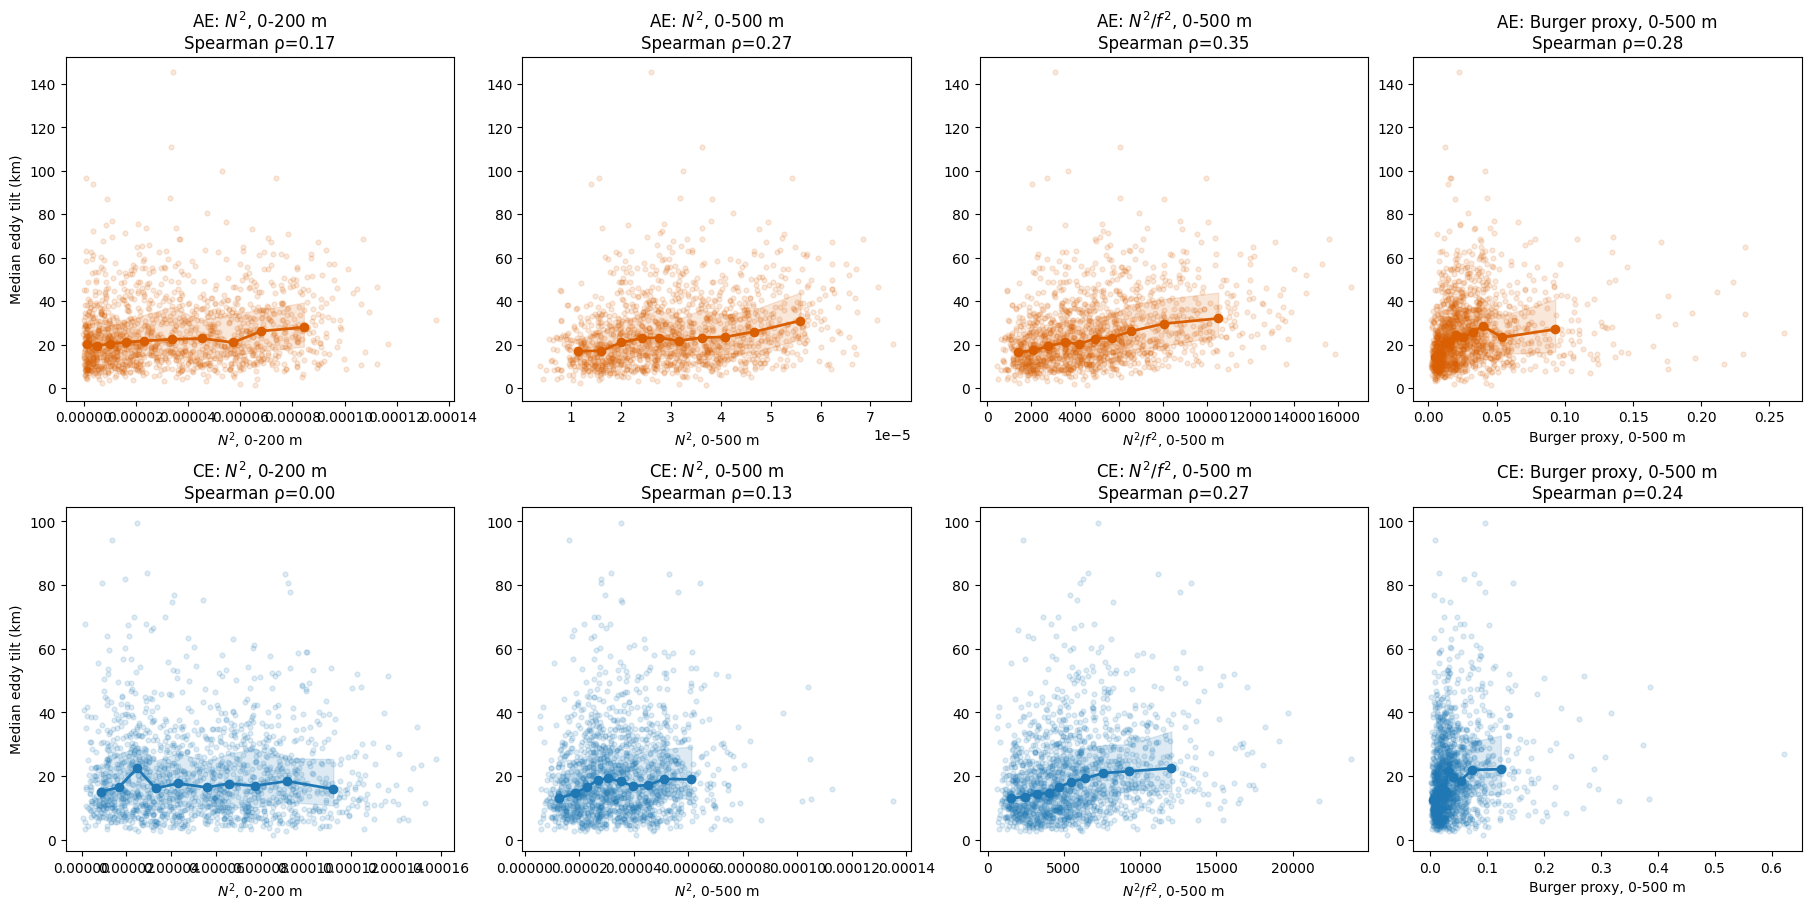

In [18]:
relationship_predictors = {
    "N2_200m_s2": r"$N^2$, 0-200 m",
    "N2_500m_s2": r"$N^2$, 0-500 m",
    "N2_over_f2_500m": r"$N^2/f^2$, 0-500 m",
    "Bu_proxy_500m": "Burger proxy, 0-500 m",
}
test_columns = ["TiltDis", latitude_col, "Rc", "h", "beta",
                *relationship_predictors]
eddy_tests = (data.groupby(["Cyc", "Eddy"], as_index=False)[test_columns]
              .median().replace([np.inf, -np.inf], np.nan))
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
response_rows = []
for row, cyc in enumerate(["AE", "CE"]):
    for column, (predictor, label) in enumerate(relationship_predictors.items()):
        ax = axes[row, column]
        part = eddy_tests.loc[eddy_tests.Cyc == cyc, [predictor, "TiltDis"]].dropna().copy()
        rho, p = spearmanr(part[predictor], part.TiltDis)
        response_rows.append({"Cyc": cyc, "predictor": predictor, "eddies": len(part),
                              "rho": rho, "p": p})
        ax.scatter(part[predictor], part.TiltDis, s=12, alpha=.14, color=palette[cyc])
        part["bin"] = pd.qcut(part[predictor].rank(method="first"), 10, labels=False)
        binned = (part.groupby("bin").agg(
            x=(predictor, "median"), y=("TiltDis", "median"),
            low=("TiltDis", lambda values: values.quantile(.25)),
            high=("TiltDis", lambda values: values.quantile(.75))).reset_index())
        ax.plot(binned.x, binned.y, "o-", color=palette[cyc], lw=2)
        ax.fill_between(binned.x, binned.low, binned.high, color=palette[cyc], alpha=.15)
        ax.set(title=f"{cyc}: {label}\nSpearman ρ={rho:.2f}", xlabel=label,
               ylabel="Median eddy tilt (km)" if column == 0 else "")
display(pd.DataFrame(response_rows))
plt.show()


,Cyc,predictor,eddies,standardized_partial_slope,ci_low,ci_high,p
0,AE,N2_200m_s2,1422,0.119340,0.067902,0.170778,5.434981e-06
1,AE,N2_500m_s2,1422,0.134978,0.084180,0.185776,1.909585e-07
2,AE,N2_over_f2_500m,1422,0.128750,0.078236,0.179264,5.867280e-07
3,AE,Bu_proxy_500m,1422,-0.055666,-0.108209,-0.003123,3.785189e-02
4,CE,N2_200m_s2,1531,-0.132079,-0.180903,-0.083255,1.144798e-07
5,CE,N2_500m_s2,1531,-0.120210,-0.169236,-0.071185,1.540935e-06
6,CE,N2_over_f2_500m,1531,-0.118282,-0.166092,-0.070471,1.241510e-06
7,CE,Bu_proxy_500m,1531,-0.070940,-0.121637,-0.020243,6.096175e-03


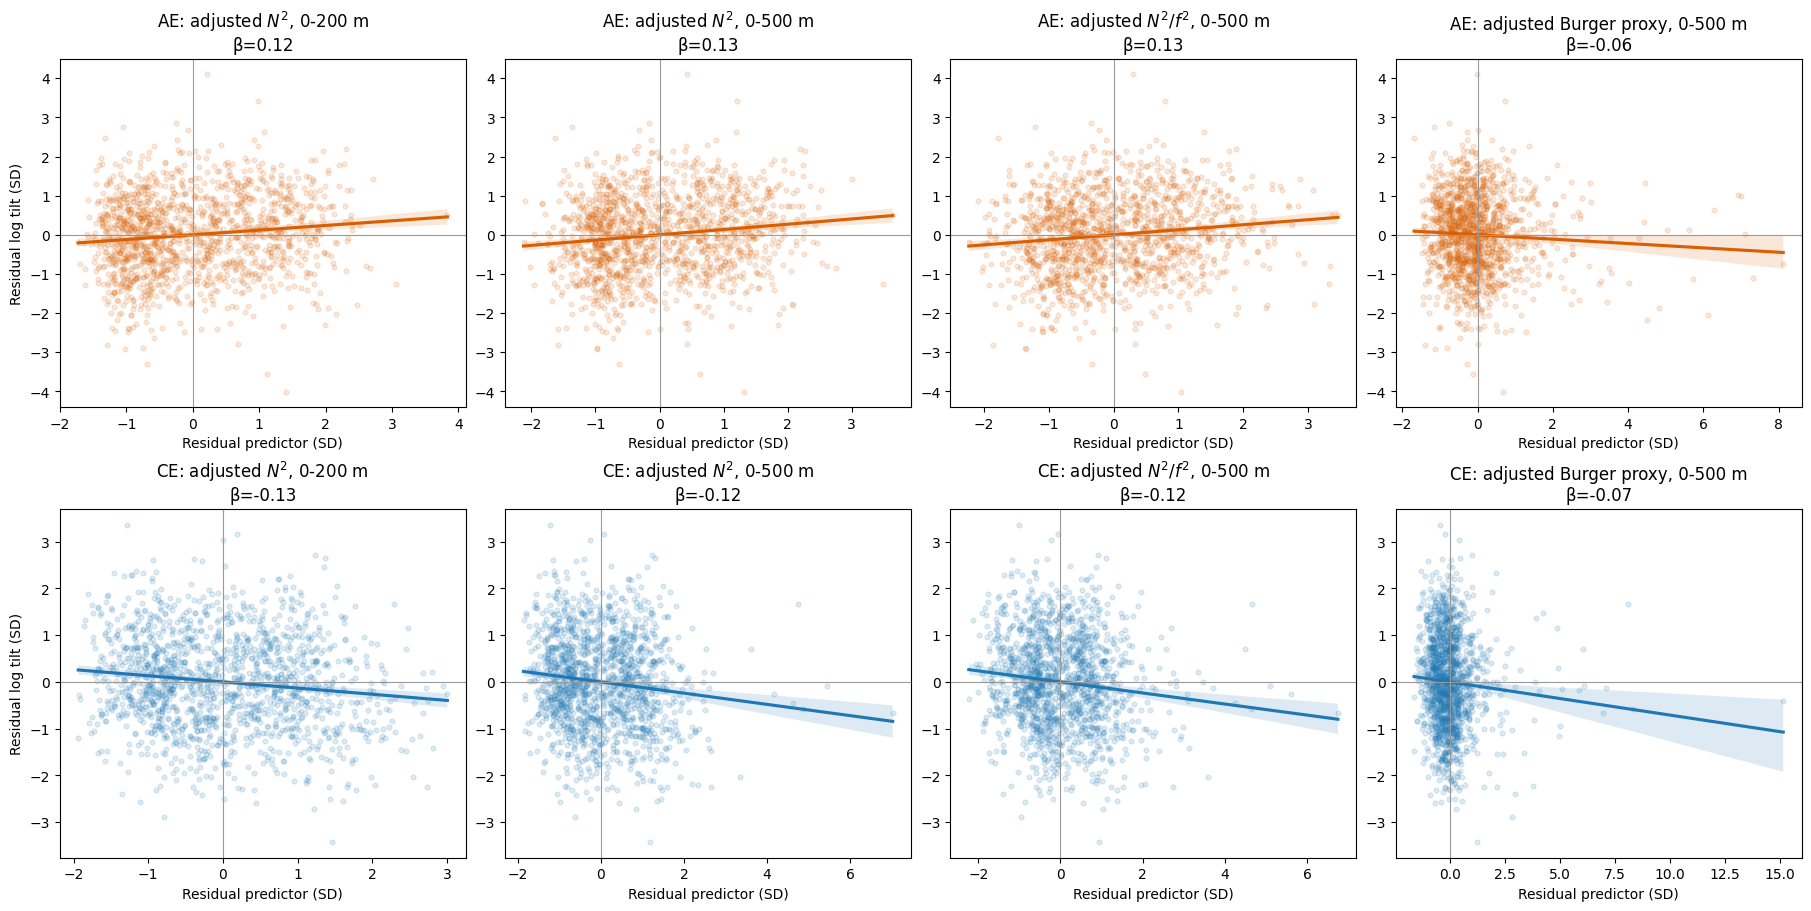

In [19]:
# Partial relationships after removing latitude curvature, Rc, and h.
eddy_tests["latitude_sq"] = eddy_tests[latitude_col] ** 2
eddy_tests["log_tilt"] = np.log1p(eddy_tests.TiltDis)
partial_rows = []
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
for row, cyc in enumerate(["AE", "CE"]):
    cyc_data = eddy_tests[eddy_tests.Cyc == cyc]
    for column, (predictor, label) in enumerate(relationship_predictors.items()):
        residuals = mech.residualise_against_controls(
            cyc_data, ["log_tilt", predictor],
            [latitude_col, "latitude_sq", "Rc", "h"])
        residuals["x_std"] = residuals[f"{predictor}_resid"] / residuals[f"{predictor}_resid"].std()
        residuals["y_std"] = residuals["log_tilt_resid"] / residuals["log_tilt_resid"].std()
        fit = smf.ols("y_std ~ x_std", data=residuals).fit(cov_type="HC3")
        interval = fit.conf_int().loc["x_std"]
        partial_rows.append({"Cyc": cyc, "predictor": predictor, "eddies": len(residuals),
                             "standardized_partial_slope": fit.params["x_std"],
                             "ci_low": interval.iloc[0], "ci_high": interval.iloc[1],
                             "p": fit.pvalues["x_std"]})
        ax = axes[row, column]
        ax.scatter(residuals.x_std, residuals.y_std, s=12, alpha=.14, color=palette[cyc])
        sns.regplot(data=residuals, x="x_std", y="y_std", scatter=False,
                    color=palette[cyc], ax=ax)
        ax.axhline(0, color="0.6", lw=.8); ax.axvline(0, color="0.6", lw=.8)
        ax.set(title=f"{cyc}: adjusted {label}\nβ={fit.params['x_std']:.2f}",
               xlabel="Residual predictor (SD)",
               ylabel="Residual log tilt (SD)" if column == 0 else "")
partial_results = pd.DataFrame(partial_rows)
display(partial_results)
plt.show()


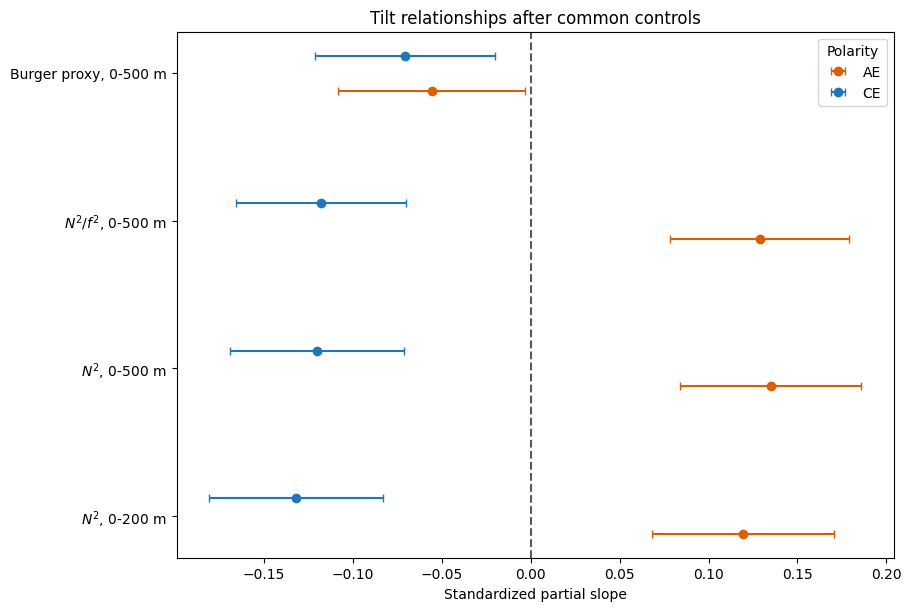

,predictor,CE_minus_AE_parameterization,interaction,ci_low,ci_high,p
0,N2_200m_s2,z_N2_200m_s2:C(Cyc)[T.CE],-0.127034,-0.166314,-0.087754,2.317902e-10
1,N2_500m_s2,z_N2_500m_s2:C(Cyc)[T.CE],-0.098960,-0.136245,-0.061676,1.970648e-07
2,N2_over_f2_500m,z_N2_over_f2_500m:C(Cyc)[T.CE],-0.059393,-0.096250,-0.022535,1.586761e-03
3,Bu_proxy_500m,z_Bu_proxy_500m:C(Cyc)[T.CE],0.035241,-0.008776,0.079258,1.166070e-01


In [20]:
# Forest plot and formal AE-versus-CE slope interaction tests.
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
plot_order = list(relationship_predictors)
offset = {"AE": -.12, "CE": .12}
for cyc in ["AE", "CE"]:
    part = partial_results[partial_results.Cyc == cyc].set_index("predictor").reindex(plot_order)
    y = np.arange(len(plot_order)) + offset[cyc]
    ax.errorbar(part.standardized_partial_slope, y,
                xerr=[part.standardized_partial_slope - part.ci_low,
                      part.ci_high - part.standardized_partial_slope],
                fmt="o", capsize=3, color=palette[cyc], label=cyc)
ax.axvline(0, color="0.35", ls="--")
ax.set_yticks(np.arange(len(plot_order)), [relationship_predictors[key] for key in plot_order])
ax.set(xlabel="Standardized partial slope", title="Tilt relationships after common controls")
ax.legend(title="Polarity")
plt.show()
interaction_rows = []
for predictor in relationship_predictors:
    use = eddy_tests[["Cyc", "log_tilt", predictor, latitude_col,
                      "latitude_sq", "Rc", "h"]].dropna().copy()
    for column in [predictor, latitude_col, "latitude_sq", "Rc", "h"]:
        use[f"z_{column}"] = (use[column] - use[column].mean()) / use[column].std()
    interaction_fit = smf.ols(
        f"log_tilt ~ z_{predictor} * C(Cyc) + z_{latitude_col} + z_latitude_sq + z_Rc + z_h",
        data=use).fit(cov_type="HC3")
    term = next(name for name in interaction_fit.params.index
                if name != f"z_{predictor}" and f"z_{predictor}" in name and "C(Cyc)" in name)
    interval = interaction_fit.conf_int().loc[term]
    interaction_rows.append({"predictor": predictor, "CE_minus_AE_parameterization": term,
                             "interaction": interaction_fit.params[term],
                             "ci_low": interval.iloc[0], "ci_high": interval.iloc[1],
                             "p": interaction_fit.pvalues[term]})
display(pd.DataFrame(interaction_rows))


,Cyc,latitude_block,predictor,eddies,rho,ci_low,ci_high,p
0,AE,"(-40.647999999999996, -37.926]",N2_200m_s2,313,0.117323,0.006545,0.225256,3.803047e-02
1,AE,"(-40.647999999999996, -37.926]",N2_500m_s2,313,0.091646,-0.019415,0.200472,1.055986e-01
2,AE,"(-40.647999999999996, -37.926]",N2_over_f2_500m,313,0.089144,-0.021936,0.198049,1.155014e-01
3,AE,"(-40.647999999999996, -37.926]",Bu_proxy_500m,313,0.251304,0.144466,0.352350,6.774119e-06
4,AE,"(-37.926, -35.684]",N2_200m_s2,287,0.230805,0.118180,0.337567,7.932207e-05
5,AE,"(-37.926, -35.684]",N2_500m_s2,287,0.202940,0.089255,0.311406,5.420098e-04
6,AE,"(-37.926, -35.684]",N2_over_f2_500m,287,0.201125,0.087377,0.309696,6.091769e-04
7,AE,"(-37.926, -35.684]",Bu_proxy_500m,287,0.393043,0.290479,0.486679,4.860677e-12
8,AE,"(-35.684, -32.968]",N2_200m_s2,292,0.052999,-0.062166,0.166770,3.668493e-01
9,AE,"(-35.684, -32.968]",N2_500m_s2,292,0.058772,-0.056394,0.172395,3.168942e-01


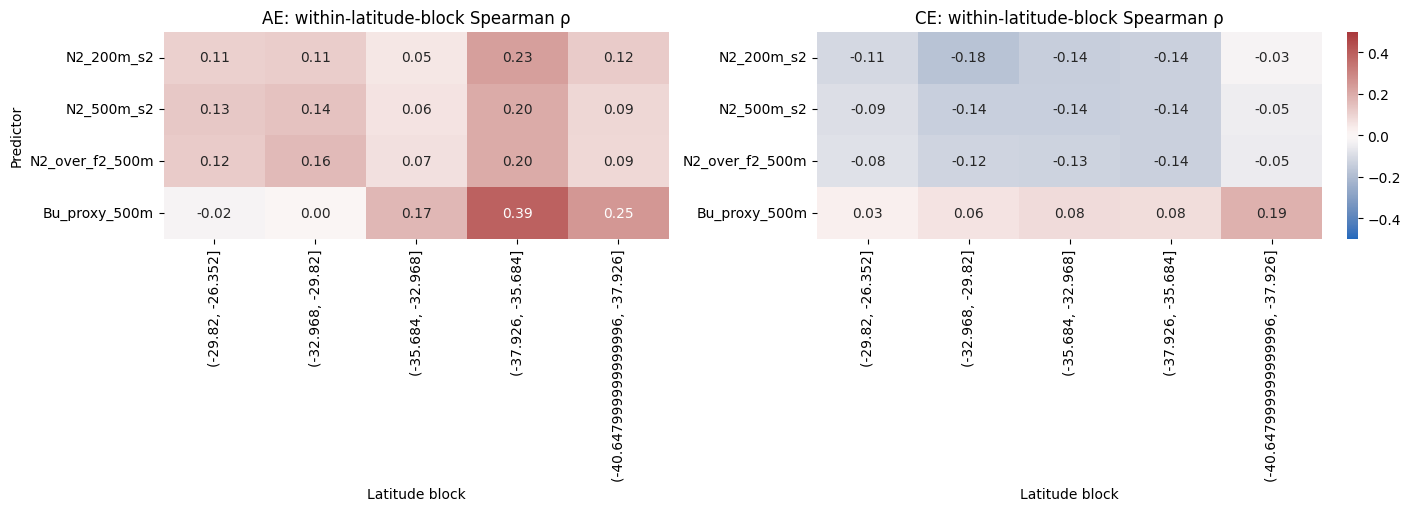

In [21]:
# Within-latitude-band correlations test whether one basin-scale gradient drives everything.
eddy_tests["latitude_block"] = pd.qcut(eddy_tests[latitude_col], 5, duplicates="drop")
block_rows = []
for (cyc, block), part in eddy_tests.groupby(["Cyc", "latitude_block"], observed=True):
    for predictor in relationship_predictors:
        use = part[[predictor, "TiltDis"]].dropna()
        rho, p = spearmanr(use[predictor], use.TiltDis)
        if len(use) > 3 and np.isfinite(rho):
            z = np.arctanh(np.clip(rho, -.999999, .999999)); se = 1 / np.sqrt(len(use) - 3)
            low, high = np.tanh([z - 1.96 * se, z + 1.96 * se])
        else:
            low, high = np.nan, np.nan
        block_rows.append({"Cyc": cyc, "latitude_block": str(block),
                           "predictor": predictor, "eddies": len(use), "rho": rho,
                           "ci_low": low, "ci_high": high, "p": p})
block_results = pd.DataFrame(block_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, cyc in zip(axes, ["AE", "CE"]):
    matrix = (block_results[block_results.Cyc == cyc]
              .pivot(index="predictor", columns="latitude_block", values="rho")
              .reindex(index=plot_order))
    sns.heatmap(matrix, vmin=-.5, vmax=.5, center=0, cmap="vlag", annot=True, fmt=".2f",
                ax=ax, cbar=ax is axes[-1])
    ax.set(title=f"{cyc}: within-latitude-block Spearman ρ", xlabel="Latitude block",
           ylabel="Predictor" if ax is axes[0] else "")
display(block_results)
plt.show()


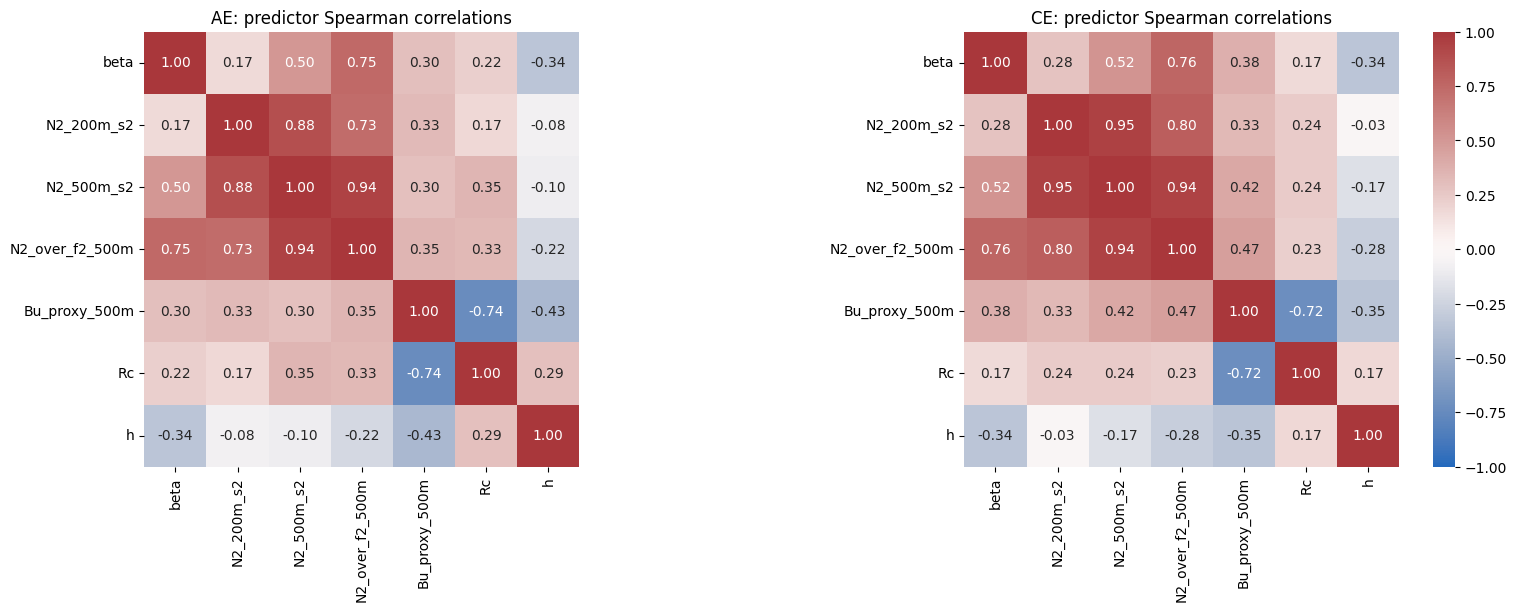

,Cyc,predictor,eddies,quadratic_estimate,quadratic_p,delta_AIC_quadratic_minus_linear
0,AE,N2_200m_s2,1422,-0.014460,0.287345,0.914064
1,AE,N2_500m_s2,1422,-0.011556,0.346688,1.089986
2,AE,N2_over_f2_500m,1422,-0.022277,0.052734,-1.848208
3,AE,Bu_proxy_500m,1422,-0.013484,0.088657,-1.585030
4,CE,N2_200m_s2,1531,-0.021894,0.065374,-1.027623
5,CE,N2_500m_s2,1531,0.001754,0.811602,1.953964
6,CE,N2_over_f2_500m,1531,0.008843,0.311907,1.228832
7,CE,Bu_proxy_500m,1531,0.008730,0.334416,-1.878538


In [22]:
# Collinearity and quadratic-response checks guard against over-interpreting proxies.
correlation_columns = ["beta", "N2_200m_s2", "N2_500m_s2",
                       "N2_over_f2_500m", "Bu_proxy_500m", "Rc", "h"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for ax, cyc in zip(axes, ["AE", "CE"]):
    matrix = eddy_tests.loc[eddy_tests.Cyc == cyc, correlation_columns].corr(method="spearman")
    sns.heatmap(matrix, vmin=-1, vmax=1, center=0, cmap="vlag", annot=True, fmt=".2f",
                square=True, ax=ax, cbar=ax is axes[-1])
    ax.set_title(f"{cyc}: predictor Spearman correlations")
plt.show()
nonlinear_rows = []
for cyc, part in eddy_tests.groupby("Cyc"):
    for predictor in relationship_predictors:
        use = part[["log_tilt", predictor, latitude_col, "latitude_sq", "Rc", "h"]].dropna().copy()
        for column in [predictor, latitude_col, "latitude_sq", "Rc", "h"]:
            use[f"z_{column}"] = (use[column] - use[column].mean()) / use[column].std()
        base = f"log_tilt ~ z_{predictor} + z_{latitude_col} + z_latitude_sq + z_Rc + z_h"
        linear = smf.ols(base, data=use).fit(cov_type="HC3")
        quadratic = smf.ols(base + f" + I(z_{predictor} ** 2)", data=use).fit(cov_type="HC3")
        quadratic_term = f"I(z_{predictor} ** 2)"
        nonlinear_rows.append({"Cyc": cyc, "predictor": predictor, "eddies": len(use),
                               "quadratic_estimate": quadratic.params[quadratic_term],
                               "quadratic_p": quadratic.pvalues[quadratic_term],
                               "delta_AIC_quadratic_minus_linear": quadratic.aic - linear.aic})
display(pd.DataFrame(nonlinear_rows))


,category,Cyc,eddies_low_medium_high,median_high_minus_low_km,bootstrap_ci_low,bootstrap_ci_high,kruskal_H,kruskal_p
0,N2Class,AE,"(475, 468, 479)",7.893168,5.570652,9.953618,80.951819,2.639586e-18
1,N2Class,CE,"(512, 509, 510)",2.966242,1.680721,4.686654,19.024001,7.395894e-05
2,N2ClassLatitudeAdjusted,AE,"(478, 471, 473)",3.641656,1.194885,5.886134,12.670956,1.772298e-03
3,N2ClassLatitudeAdjusted,CE,"(511, 509, 511)",-3.129513,-4.830394,-1.048713,18.787988,8.322241e-05


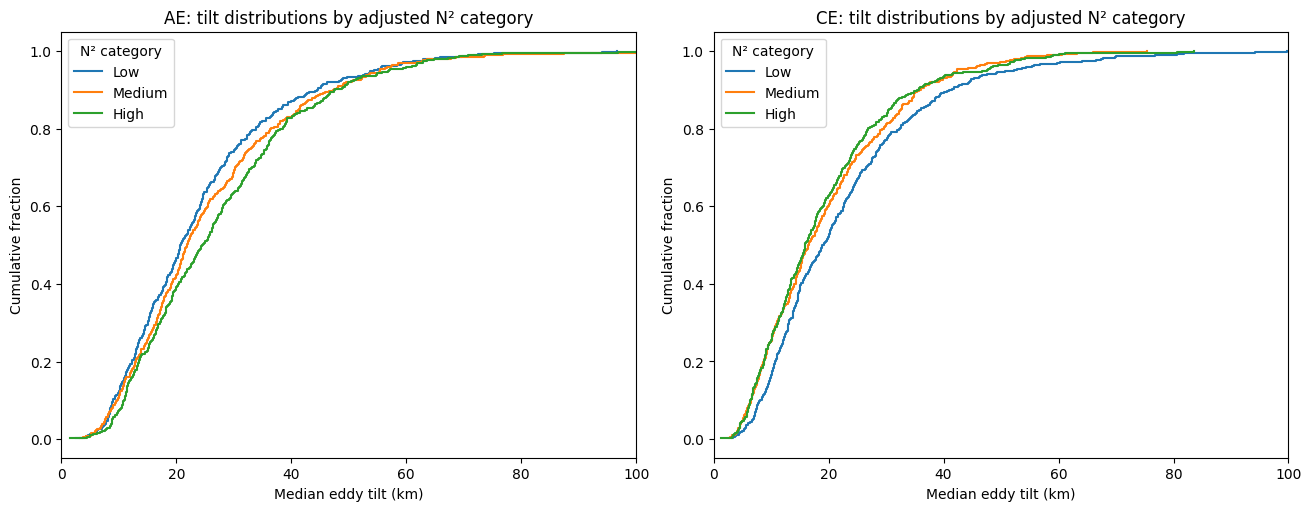

In [23]:
# Category tests and bootstrapped high-minus-low median tilt differences.
from scipy.stats import kruskal
rng = np.random.default_rng(20260824)
category_rows = []
for category_column in ["N2Class", "N2ClassLatitudeAdjusted"]:
    for cyc, part in eddy_strat.groupby("Cyc"):
        groups = [part.loc[part[category_column] == label, "TiltDis"].dropna().to_numpy()
                  for label in order]
        statistic, p = kruskal(*groups)
        observed_difference = np.median(groups[2]) - np.median(groups[0])
        boot = np.array([
            np.median(rng.choice(groups[2], len(groups[2]), replace=True)) -
            np.median(rng.choice(groups[0], len(groups[0]), replace=True))
            for _ in range(2000)])
        category_rows.append({"category": category_column, "Cyc": cyc,
                              "eddies_low_medium_high": tuple(map(len, groups)),
                              "median_high_minus_low_km": observed_difference,
                              "bootstrap_ci_low": np.percentile(boot, 2.5),
                              "bootstrap_ci_high": np.percentile(boot, 97.5),
                              "kruskal_H": statistic, "kruskal_p": p})
category_tests = pd.DataFrame(category_rows)
display(category_tests)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, cyc in zip(axes, ["AE", "CE"]):
    part = eddy_strat[eddy_strat.Cyc == cyc]
    for label in order:
        values = np.sort(part.loc[part.N2ClassLatitudeAdjusted == label, "TiltDis"].dropna())
        ax.step(values, np.arange(1, len(values) + 1) / len(values), where="post", label=label)
    ax.set(title=f"{cyc}: tilt distributions by adjusted N² category",
           xlabel="Median eddy tilt (km)", ylabel="Cumulative fraction", xlim=(0, 100))
    ax.legend(title="N² category")
plt.show()


,Cyc,model,estimate,ci_low,ci_high
0,AE,plus_beta,0.278897,0.247182,0.310612
1,AE,plus_N2,0.120702,0.085331,0.156073
2,AE,N2_over_f2,0.135658,0.093827,0.177488
3,AE,Burger_proxy,0.012968,-0.016894,0.042829
4,CE,plus_beta,0.284440,0.257166,0.311713
5,CE,plus_N2,-0.069234,-0.095493,-0.042975
6,CE,N2_over_f2,-0.073538,-0.105590,-0.041485
7,CE,Burger_proxy,-0.015590,-0.039179,0.008000


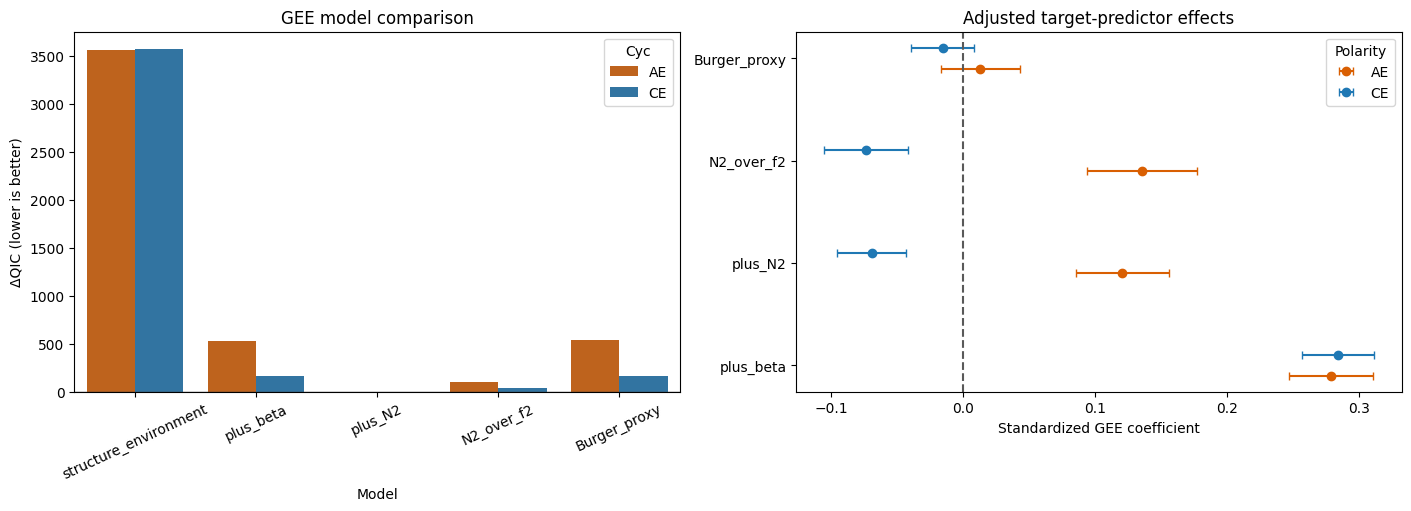

In [24]:
# Visualise model support and adjusted GEE coefficients from the repeated eddy-day analysis.
comparison_plot = pd.DataFrame(comparison).copy()
comparison_plot["delta_QIC"] = comparison_plot.QIC - comparison_plot.groupby("Cyc").QIC.transform("min")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.barplot(data=comparison_plot, x="model", y="delta_QIC", hue="Cyc",
            hue_order=["AE", "CE"], palette=palette, ax=axes[0])
axes[0].axhline(0, color="0.3", lw=1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].set(title="GEE model comparison", xlabel="Model", ylabel="ΔQIC (lower is better)")
effect_rows = []
target_terms = {"plus_beta": "z_beta", "plus_N2": "z_N2_500m_s2",
                "N2_over_f2": "z_N2_over_f2_500m",
                "Burger_proxy": "z_Bu_proxy_500m"}
for (cyc, model), fit in fits.items():
    if model not in target_terms:
        continue
    term = target_terms[model]; interval = fit.conf_int().loc[term]
    effect_rows.append({"Cyc": cyc, "model": model, "estimate": fit.params[term],
                        "ci_low": interval.iloc[0], "ci_high": interval.iloc[1]})
effects = pd.DataFrame(effect_rows)
model_order = list(target_terms)
for cyc, shift in [("AE", -.1), ("CE", .1)]:
    part = effects[effects.Cyc == cyc].set_index("model").reindex(model_order)
    y = np.arange(len(model_order)) + shift
    axes[1].errorbar(part.estimate, y, xerr=[part.estimate - part.ci_low,
                                                part.ci_high - part.estimate],
                     fmt="o", capsize=3, color=palette[cyc], label=cyc)
axes[1].axvline(0, color="0.35", ls="--")
axes[1].set_yticks(np.arange(len(model_order)), model_order)
axes[1].set(title="Adjusted target-predictor effects", xlabel="Standardized GEE coefficient")
axes[1].legend(title="Polarity")
display(effects)
plt.show()


## Interpretation guardrail

Call the equatorward pattern specifically beta-related only if beta adds information beyond structure, bathymetry, stratification and shear and survives spatial blocking. `Rd_proxy` and `Bu_proxy` are constant-N screening proxies, not solved vertical modes; label them as such in figures and text.
